In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import TensorBoard
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import os
import datetime
import json
import joblib

In [4]:
os.makedirs("../results/LSTM_Group", exist_ok=True)
os.makedirs("../logs/fit/LSTM_Group", exist_ok=True)

In [5]:
log_dir = "../logs/fit/LSTM_Group/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)


In [6]:
df = pd.read_csv("../day_approach_maskedID_timeseries.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by=["Athlete ID", "Date"])

In [7]:
n_timesteps = 16 # 16 is the best
feature_cols = []

for col in df.columns:
    if col not in ["Athlete ID", "Date", "injury"]:
        feature_cols.append(col)

In [8]:
X, y = [], []

for _, group in df.groupby("Athlete ID"):
    group_features = group[feature_cols].values
    group_labels = group["injury"].values

    for i in range(len(group) - n_timesteps):
        X.append(group_features[i : i + n_timesteps])
        y.append(group_labels[i + n_timesteps])  

X = np.array(X)
y = np.array(y)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X.shape[-1])).reshape(X_test.shape)

class_weights = class_weight.compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

model = keras.Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(n_timesteps, X.shape[-1])),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


d:\Anaconda\envs\SAT5114\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[tensorboard_callback],
    verbose=1
)

Epoch 1/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5263 - loss: 0.7050 - val_accuracy: 0.6267 - val_loss: 0.5826
Epoch 2/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5607 - loss: 0.7022 - val_accuracy: 0.7192 - val_loss: 0.6009
Epoch 3/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6754 - loss: 0.6310 - val_accuracy: 0.2495 - val_loss: 0.7561
Epoch 4/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5301 - loss: 0.6612 - val_accuracy: 0.6298 - val_loss: 0.6771
Epoch 5/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5943 - loss: 0.6393 - val_accuracy: 0.6864 - val_loss: 0.6049
Epoch 6/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6813 - loss: 0.6291 - val_accuracy: 0.6669 - val_loss: 0.6067
Epoch 7/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7237 - loss: 0.5549 - val_accuracy: 0.6739 - val_loss: 0.7090
Epoch 8/50
520/520 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7511 - loss: 0.5203 - val_acc

In [11]:
model.save("../results/LSTM_Group/lstm_injury_prediction_model.h5")
joblib.dump(scaler, "../results/LSTM_Group/scaler.pkl")

with open("../results/LSTM_Group/training_history.json", "w") as f:
    json.dump(history.history, f)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))

260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.9604424672357821
AUC-ROC: 0.7096850689343988
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      8206
           1       0.14      0.38      0.20       111

    accuracy                           0.96      8317
   macro avg       0.57      0.67      0.59      8317
weighted avg       0.98      0.96      0.97      8317



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

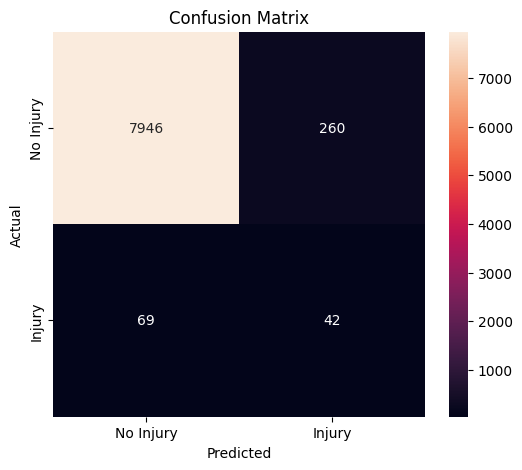

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["No Injury", "Injury"], yticklabels=["No Injury", "Injury"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()